# Config


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

import os
from dotenv import load_dotenv

from entsoe import EntsoePandasClient

load_dotenv()

# ENTSOE Token
entsoe_token = os.getenv("ENTSOE_API_TOKEN")

# ENTSOE Client
entsoe_client = EntsoePandasClient(api_key=entsoe_token)

# Fetch Actual & FCST Load

In [2]:
# Location
country_capital = "Madrid"
country_code = "ES"


# Period
today = pd.Timestamp.now(
    tz=f"Europe/{country_capital}"
).normalize()

yesterday=(pd.Timestamp.now(tz=f"Europe/{country_capital}")
    .normalize()
    - pd.Timedelta(days=1)
)
last_week=(pd.Timestamp.now(tz=f"Europe/{country_capital}")
    .normalize()
    - pd.Timedelta(days=7)
)

tomorrow =(pd.Timestamp.now(tz=f"Europe/{country_capital}")
    .normalize()
    + pd.Timedelta(days=1)
)


start=last_week
end=today


# ENTSOE Client
df = entsoe_client.query_load_and_forecast(
    country_code=country_code,
    start=last_week,
    end=today)

# EDA

In [3]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 672 entries, 2026-08-30 00:00:00+02:00 to 2026-09-05 23:45:00+02:00
Freq: 15min
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Forecasted Load  672 non-null    float64
 1   Actual Load      672 non-null    float64
dtypes: float64(2)
memory usage: 15.8 KB


In [4]:
 df.describe().T

,count,mean,std,min,25%,50%,75%,max
Forecasted Load,672.0,29733.907738,4392.266710,20544.0,26079.0,30389.0,33221.75,37331.0
Actual Load,672.0,29887.535714,4673.148102,20472.0,25843.0,30788.0,33528.00,38240.0


In [5]:
df.head()

,Forecasted Load,Actual Load
2026-08-30 00:00:00+02:00,24764.0,24592.0
2026-08-30 00:15:00+02:00,24415.0,24228.0
2026-08-30 00:30:00+02:00,24067.0,23752.0
2026-08-30 00:45:00+02:00,23722.0,23368.0
2026-08-30 01:00:00+02:00,23361.0,23108.0


In [6]:
df.tail()

,Forecasted Load,Actual Load
2026-09-05 22:45:00+02:00,30353.0,30332.0
2026-09-05 23:00:00+02:00,29871.0,29832.0
2026-09-05 23:15:00+02:00,29452.0,29544.0
2026-09-05 23:30:00+02:00,29051.0,28796.0
2026-09-05 23:45:00+02:00,28662.0,28324.0


In [7]:
# Check that timestamps are unique
assert df.index.is_unique

# Check that timestamps are sorted
assert df.index.is_monotonic_increasing

In [8]:
pivot = pd.pivot_table(
    df,
    values=["Actual Load", "Forecasted Load"],
    index=df.index.date,
    aggfunc="mean"
)

pivot["Delta"] = pivot["Actual Load"] - pivot["Forecasted Load"]

print(pivot.round(2))

            Actual Load  Forecasted Load   Delta
2026-08-30     23545.50         23883.27 -337.77
2026-08-31     28567.42         28534.60   32.81
2026-09-01     30565.04         29935.17  629.88
2026-09-02     31536.25         31167.77  368.48
2026-09-03     32663.50         32328.82  334.68
2026-09-04     33004.54         32941.21   63.33
2026-09-05     29330.50         29346.51  -16.01


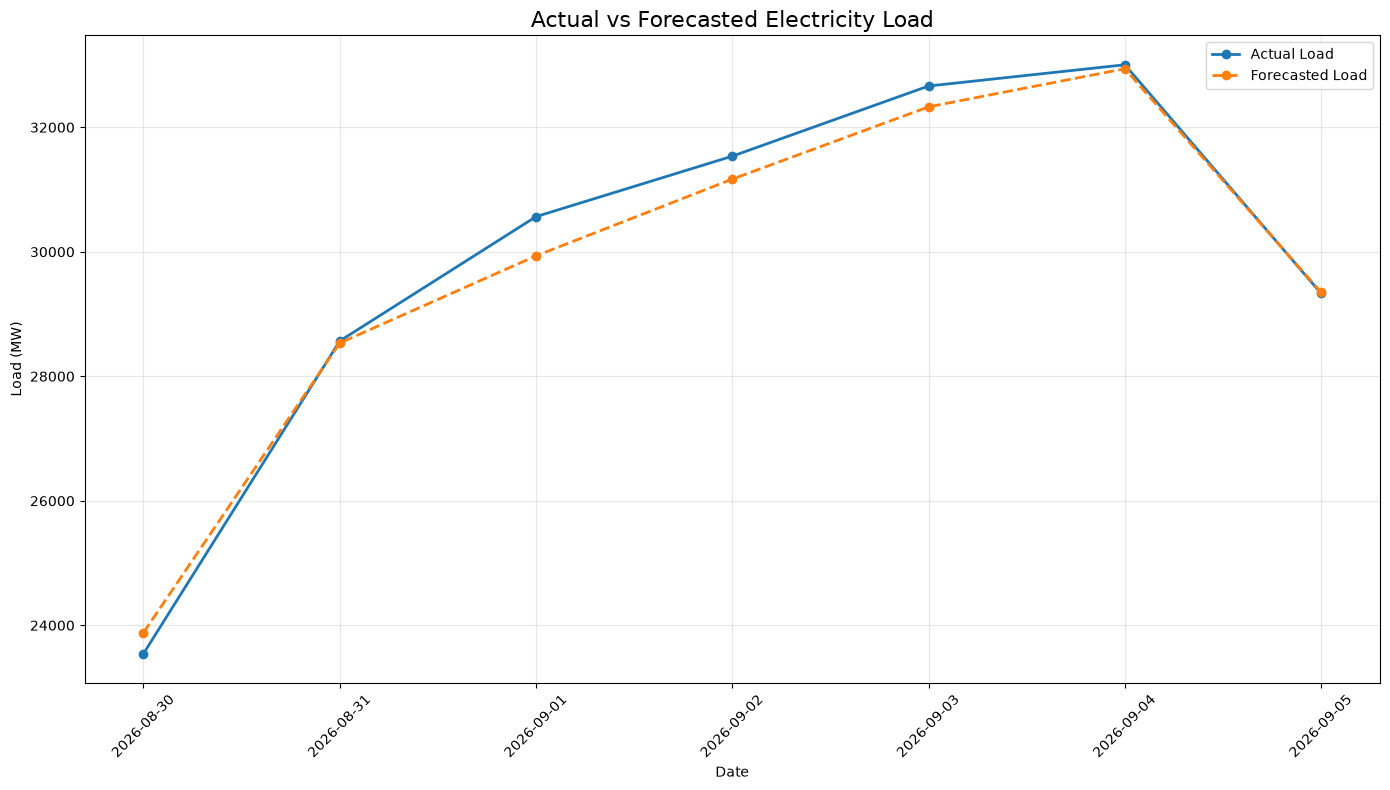

In [9]:
# Plot \Actual vs Forecasted Electricity Load/



plt.figure(figsize=(14, 8))

plt.plot(
    pivot.index,
    pivot["Actual Load"],
    marker="o",
    linewidth=2,
    label="Actual Load"
)

plt.plot(
    pivot.index,
    pivot["Forecasted Load"],
    marker="o",
    linewidth=2,
    linestyle="--",
    label="Forecasted Load"
)

plt.title("Actual vs Forecasted Electricity Load", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Load (MW)")
plt.legend()
plt.grid(alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

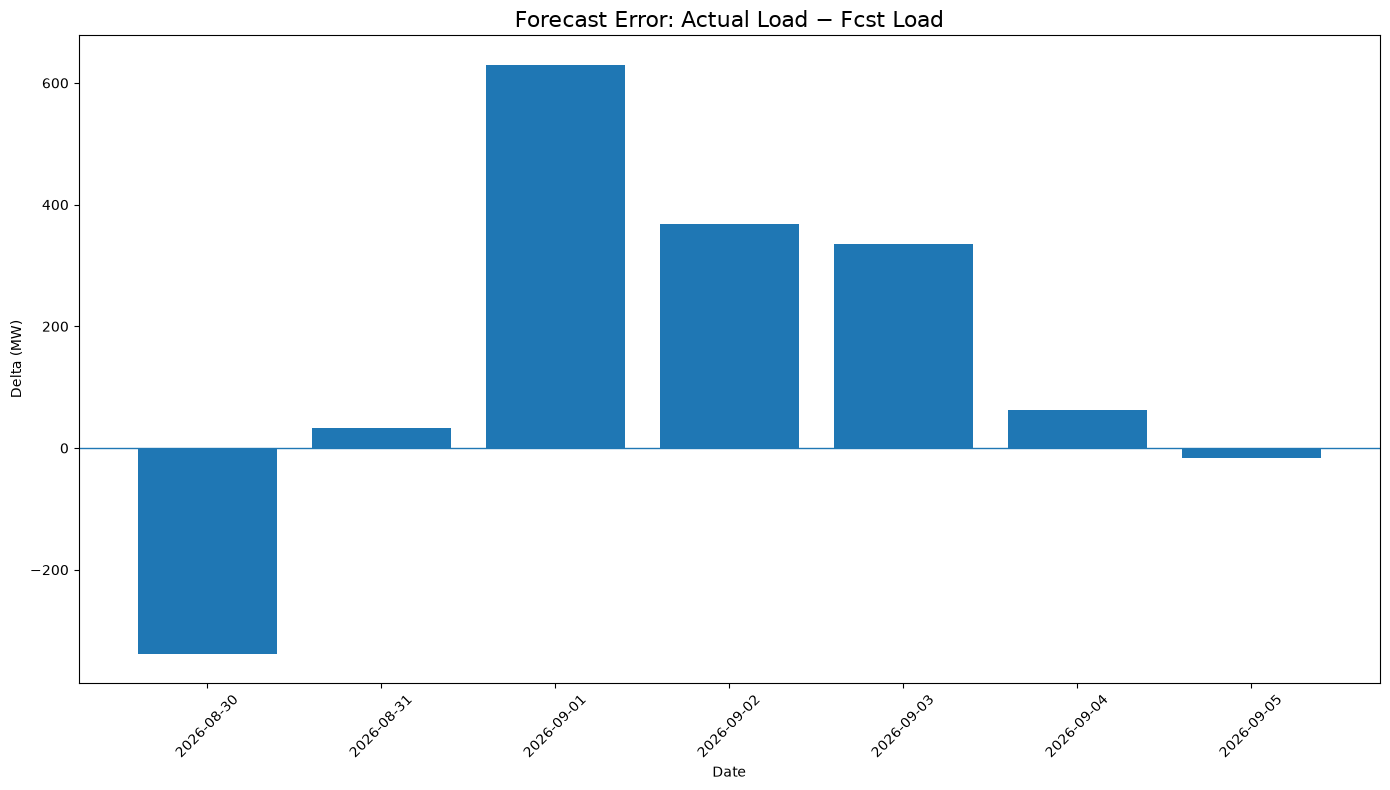

In [10]:
# Plot \Forecast Error: Actual Load − Fcst Load/

plt.figure(figsize=(14, 8))

plt.bar(
    pivot.index,
    pivot["Delta"]
)

plt.axhline(
    y=0,
    linewidth=1
)

plt.title("Forecast Error: Actual Load − Fcst Load", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Delta (MW)")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()